In [11]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC
import time
import joblib

# 1. Load Data
data = np.load('../data/fashion_data_complete.npz')
X_train_small = data['X_train'][:10000] # Use subset for tuning
y_train_small = data['y_train'][:10000]
X_val = data['X_val']
y_val = data['y_val']



--- Class Distribution in y_val ---
T-shirt     : 1000 samples (10.0%)
Trouser     : 1000 samples (10.0%)
Pullover    : 1000 samples (10.0%)
Dress       : 1000 samples (10.0%)
Coat        : 1000 samples (10.0%)
Sandal      : 1000 samples (10.0%)
Shirt       : 1000 samples (10.0%)
Sneaker     : 1000 samples (10.0%)
Bag         : 1000 samples (10.0%)
Ankle boot  : 1000 samples (10.0%)


C:\Users\ACER\AppData\Local\Temp\ipykernel_55204\800590172.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_names, y=counts, palette="viridis")


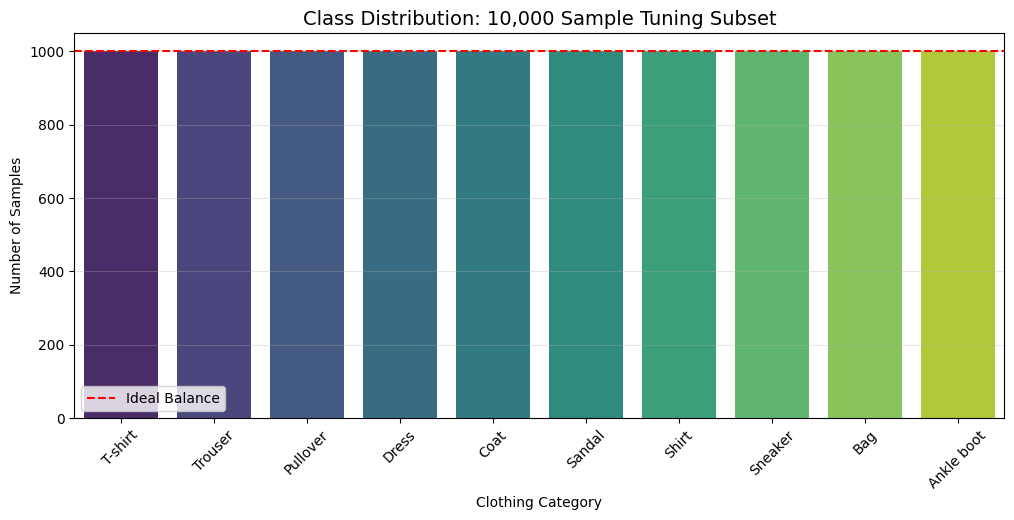

In [20]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get unique classes and their counts
unique, counts = np.unique(y_val, return_counts=True)

# 2. Map indices to Class Names (for better readability)
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 3. Print numerical results
print("--- Class Distribution in y_val ---")
for i in range(len(unique)):
    print(f"{class_names[i]:<12}: {counts[i]} samples ({(counts[i]/len(y_val))*100:.1f}%)")

# 4. Create Visualization for Report
plt.figure(figsize=(12, 5))
sns.barplot(x=class_names, y=counts, palette="viridis")
plt.axhline(y=len(y_val)/10, color='red', linestyle='--', label='Ideal Balance')

plt.title('Class Distribution: 10,000 Sample Tuning Subset', fontsize=14)
plt.xlabel('Clothing Category')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

--- Class Distribution in y_train_small ---
T-shirt     : 1013 samples (10.1%)
Trouser     : 1015 samples (10.2%)
Pullover    : 969 samples (9.7%)
Dress       : 962 samples (9.6%)
Coat        : 1035 samples (10.3%)
Sandal      : 995 samples (10.0%)
Shirt       : 949 samples (9.5%)
Sneaker     : 1005 samples (10.1%)
Bag         : 1010 samples (10.1%)
Ankle boot  : 1047 samples (10.5%)


C:\Users\ACER\AppData\Local\Temp\ipykernel_55204\3235934935.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=class_names, y=counts, palette="viridis")


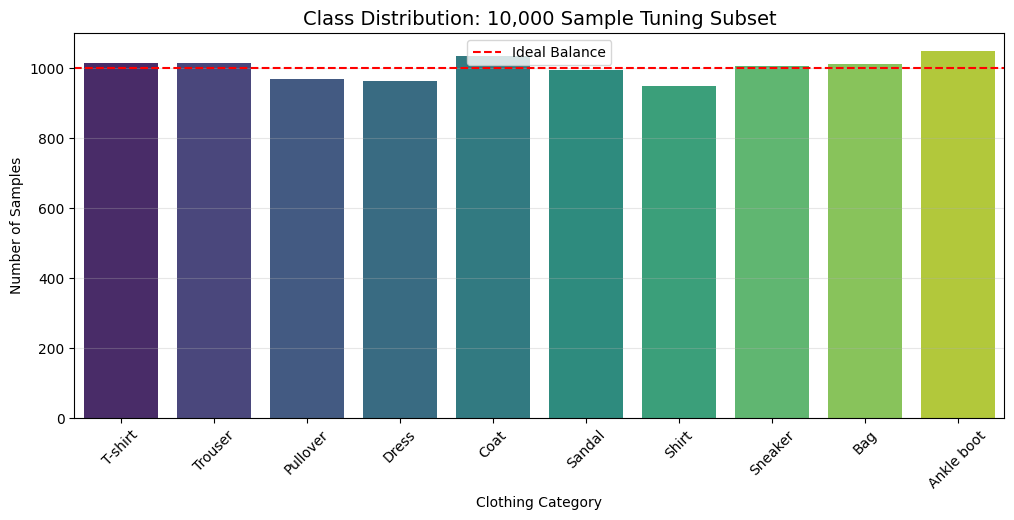

In [19]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Get unique classes and their counts
unique, counts = np.unique(y_train_small, return_counts=True)

# 2. Map indices to Class Names (for better readability)
class_names = ['T-shirt', 'Trouser', 'Pullover', 'Dress', 'Coat', 
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']

# 3. Print numerical results
print("--- Class Distribution in y_train_small ---")
for i in range(len(unique)):
    print(f"{class_names[i]:<12}: {counts[i]} samples ({(counts[i]/len(y_train_small))*100:.1f}%)")

# 4. Create Visualization for Report
plt.figure(figsize=(12, 5))
sns.barplot(x=class_names, y=counts, palette="viridis")
plt.axhline(y=len(y_train_small)/10, color='red', linestyle='--', label='Ideal Balance')

plt.title('Class Distribution: 10,000 Sample Tuning Subset', fontsize=14)
plt.xlabel('Clothing Category')
plt.ylabel('Number of Samples')
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', alpha=0.3)
plt.show()

In [15]:
import time
import numpy as np
import matplotlib.pyplot as plt
from sklearn.svm import SVC

# 2. Hyperparameter Grid
kernels = ['linear', 'rbf']
C_values = [0.1, 1, 10, 15,20]

# Structure to save everything
results = {
    'linear': {'acc': [], 'time': []},
    'rbf': {'acc': [], 'time': []}
}

print("Starting SVM Hyperparameter Tuning...")

for kernel in kernels:
    for c in C_values:
        start_time = time.time()
        print(f"Testing {kernel} kernel with C={c}...", end=" ")
        
        # Train model
        model = SVC(kernel=kernel, C=c, gamma='scale', cache_size=1000)
        model.fit(X_train_small, y_train_small)
        
        # Evaluation
        acc = model.score(X_val, y_val)
        duration = time.time() - start_time
        
        # SAVE DATA
        results[kernel]['acc'].append(acc)
        results[kernel]['time'].append(duration)
        
        print(f"Val Acc: {acc:.4f} | Time: {duration:.2f}s")

Starting SVM Hyperparameter Tuning...
Testing linear kernel with C=0.1... Val Acc: 0.8261 | Time: 18.12s
Testing linear kernel with C=1... Val Acc: 0.8078 | Time: 20.10s
Testing linear kernel with C=10... Val Acc: 0.8029 | Time: 23.68s
Testing linear kernel with C=15... Val Acc: 0.8025 | Time: 21.15s
Testing linear kernel with C=20... Val Acc: 0.8021 | Time: 24.53s
Testing rbf kernel with C=0.1... Val Acc: 0.7910 | Time: 53.59s
Testing rbf kernel with C=1... Val Acc: 0.8592 | Time: 41.51s
Testing rbf kernel with C=10... Val Acc: 0.8726 | Time: 43.66s
Testing rbf kernel with C=15... Val Acc: 0.8731 | Time: 42.26s
Testing rbf kernel with C=20... Val Acc: 0.8719 | Time: 37.93s


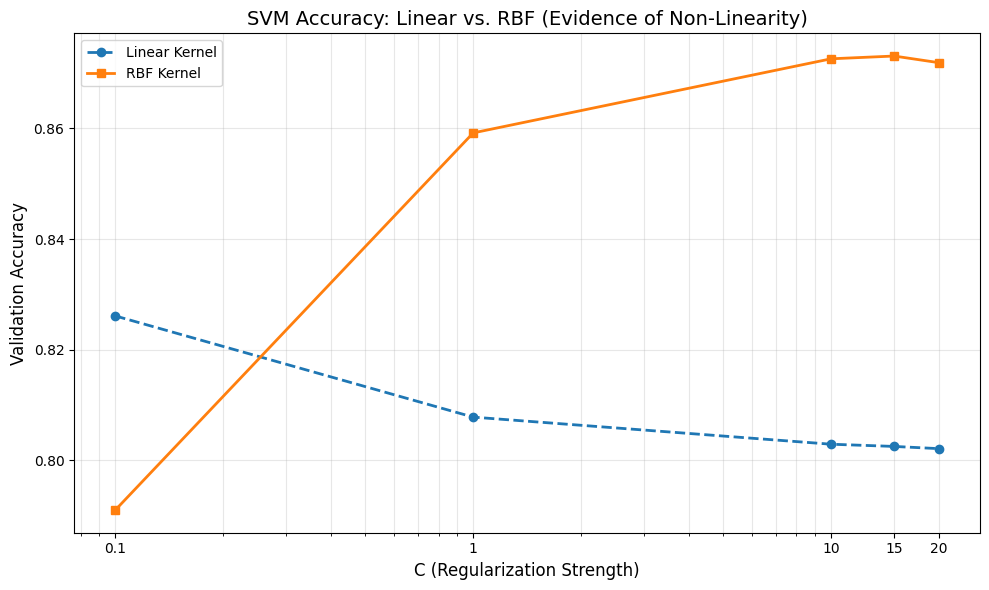

In [16]:
plt.figure(figsize=(10, 6))
plt.plot(C_values, results['linear']['acc'], label='Linear Kernel', marker='o', linestyle='--', linewidth=2)
plt.plot(C_values, results['rbf']['acc'], label='RBF Kernel', marker='s', linestyle='-', linewidth=2)

plt.xscale('log') # Important for C values
plt.xlabel('C (Regularization Strength)', fontsize=12)
plt.ylabel('Validation Accuracy', fontsize=12)
plt.title('SVM Accuracy: Linear vs. RBF (Evidence of Non-Linearity)', fontsize=14)
plt.xticks(C_values, labels=[str(c) for c in C_values])
plt.legend()
plt.grid(True, which="both", ls="-", alpha=0.3)
plt.tight_layout()
plt.show()

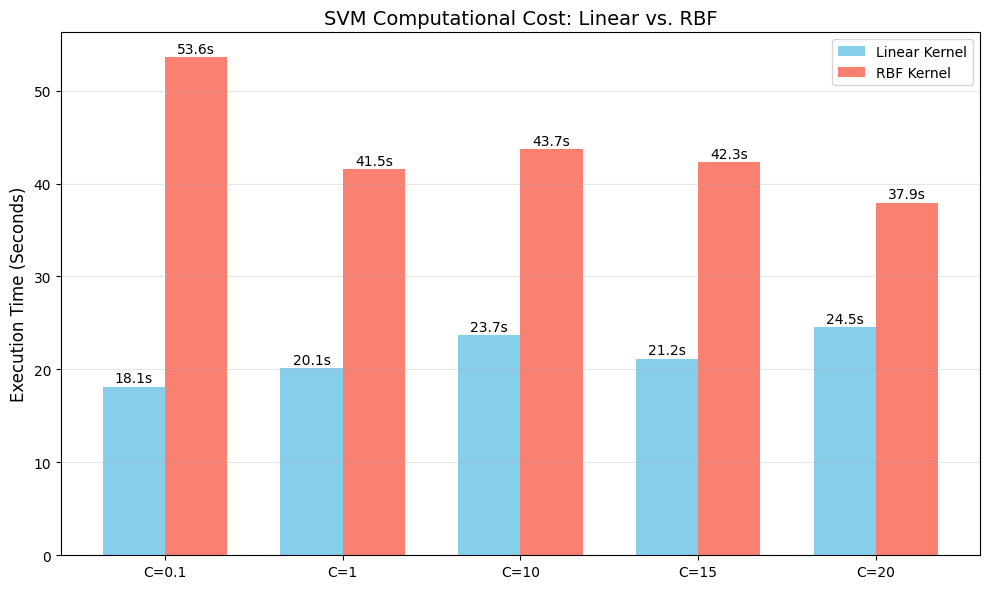

In [18]:
x = np.arange(len(C_values))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(x - width/2, results['linear']['time'], width, label='Linear Kernel', color='skyblue')
ax.bar(x + width/2, results['rbf']['time'], width, label='RBF Kernel', color='salmon')

ax.set_ylabel('Execution Time (Seconds)', fontsize=12)
ax.set_title('SVM Computational Cost: Linear vs. RBF', fontsize=14)
ax.set_xticks(x)
ax.set_xticklabels([f'C={c}' for c in C_values])
ax.legend()

# Add value labels
for i in range(len(x)):
    ax.text(x[i]-width/2, results['linear']['time'][i] + 0.5, f"{results['linear']['time'][i]:.1f}s", ha='center')
    ax.text(x[i]+width/2, results['rbf']['time'][i] + 0.5, f"{results['rbf']['time'][i]:.1f}s", ha='center')

plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()